In [12]:
# Before starting, set the right working dir and imports
import os
if 'path_to_dir' not in globals():
    path_to_dir = os.path.split(os.getcwd())[0]
os.chdir(path_to_dir)

# imports
%matplotlib inline

from sing4me import singing_extract as sing
from sing_experiments import melodies, params
from sing_experiments.params import singing_2intervals

config = singing_2intervals  # params singing extraction (from sing4me)
roving_width = 2.5
max_interval2reference = 10

roving_mean = dict(
        default=55,  # it was 55.5
        low=49,  # it was 49.5 (male)
        high=61  # it was 61.5 (female)
        )

In [39]:

import numpy as np
from scipy.io import wavfile as wave

# Set the parameters for the tone sequence
start_note = 39  # MIDI note number for the start of the sequence
end_note = 71  # MIDI note number for the end of the sequence
granularity = 0.25  # quarter-tone granularity
duration = 1.0  # duration of each tone in seconds
sampling_rate = 44100  # sampling rate in Hz
silence_duration = 1.0  # duration of silence before each tone in seconds

# Generate the sequence of tones
frequencies = []  # list to store the frequencies of the tones
for note in np.arange(start_note, end_note+granularity, granularity):
    # Convert the MIDI note number to a frequency
    frequency = 440 * 2**((note-69)/12)
    frequencies.append(frequency)

# Generate the sequence of samples for each tone
samples = []  # list to store the samples for each tone
for frequency in frequencies:
    # Generate the samples for the tone
    t = np.linspace(0, duration, int(duration*sampling_rate), False)
    tone = np.sin(2*np.pi*frequency*t)

    # Generate the samples for the silence before the tone
    t_silence = np.linspace(0, silence_duration, int(silence_duration*sampling_rate), False)
    silence = np.zeros(t_silence.shape)

    # Concatenate the silence and tone samples
    tone_with_silence = np.concatenate((silence, tone))

    # Add the tone with silence to the list of samples
    samples.append(tone_with_silence)

# Concatenate all the samples into a single array
output_samples = np.concatenate(samples)

# Save the samples to a wave file
wave.write("tones-simulation.wav", sampling_rate, output_samples)


In [41]:
print(len(frequencies))

target_pitches = np.arange(start_note, end_note+0.25, 0.25)

target_pitches = [i for i in target_pitches]

print(target_pitches)
print(len(target_pitches))

129
[39.0, 39.25, 39.5, 39.75, 40.0, 40.25, 40.5, 40.75, 41.0, 41.25, 41.5, 41.75, 42.0, 42.25, 42.5, 42.75, 43.0, 43.25, 43.5, 43.75, 44.0, 44.25, 44.5, 44.75, 45.0, 45.25, 45.5, 45.75, 46.0, 46.25, 46.5, 46.75, 47.0, 47.25, 47.5, 47.75, 48.0, 48.25, 48.5, 48.75, 49.0, 49.25, 49.5, 49.75, 50.0, 50.25, 50.5, 50.75, 51.0, 51.25, 51.5, 51.75, 52.0, 52.25, 52.5, 52.75, 53.0, 53.25, 53.5, 53.75, 54.0, 54.25, 54.5, 54.75, 55.0, 55.25, 55.5, 55.75, 56.0, 56.25, 56.5, 56.75, 57.0, 57.25, 57.5, 57.75, 58.0, 58.25, 58.5, 58.75, 59.0, 59.25, 59.5, 59.75, 60.0, 60.25, 60.5, 60.75, 61.0, 61.25, 61.5, 61.75, 62.0, 62.25, 62.5, 62.75, 63.0, 63.25, 63.5, 63.75, 64.0, 64.25, 64.5, 64.75, 65.0, 65.25, 65.5, 65.75, 66.0, 66.25, 66.5, 66.75, 67.0, 67.25, 67.5, 67.75, 68.0, 68.25, 68.5, 68.75, 69.0, 69.25, 69.5, 69.75, 70.0, 70.25, 70.5, 70.75, 71.0]
129


In [78]:
path_audio = os.path.join("input/", "tones-simulation.wav")

def analyze_audio(path):
    raw = sing.analyze(
        path,
        config,
        target_pitches=target_pitches,
        plot_options=sing.PlotOptions(
            save=True, path=os.path.join("output", "tones-simulation.png"), format="png"
        ),
    )
    raw = [
        {key: melodies.as_native_type(value) for key, value in x.items()} for x in raw
    ]

    sung_pitches = [x["median_f0"] for x in raw]

    sung_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
    sung_pitches,
    "previous_note"
    )

    target_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
        target_pitches,
        "previous_note"
    )

    stats = sing.compute_stats(
        sung_pitches,
        target_pitches,
        sung_intervals,
        target_intervals
    )

    return raw, stats


In [79]:
r1, s1 = analyze_audio(path_audio)

print(s1)

selected$("Sound")Plot saved
{'num_sung_pitches': 129, 'num_target_pitches': 129, 'raw_pitch_diffs': [0.002938372108943099, 0.0024263623207616547, 0.0031462380634508236, 0.003621550300323406, 0.003340741593362395, 0.003635818994915496, 0.0029749810729242654, 0.003162556132885186, 0.0015626748846315763, 0.00212107924556193, 0.0007141014608720297, 0.0008288624707120107, 0.000793479903585137, 0.0013223511168050095, 0.0009923672404994477, -0.0009358651487616498, 0.0008178821707645056, -0.0006660219696144054, 0.000553206956091401, 0.0005510177267211702, -0.00019616232590635718, -0.00026428860478944216, 0.0002028531022375546, 0.0002796158538842519, 0.00043830114701393086, 0.0003348047366031892, 0.0004032786666385846, 0.0002496751891527538, 0.00017051785026467314, 0.000553835099630362, -0.0001537292854294492, -0.00011773808914483652, -0.000346682781341201, -0.0008580038548728908, -0.0007586501480005836, -0.0009208455650622227, -0.0005262750743781908, -0.0004772693030261621, -0.000435874884175

In [77]:
r2, s2 = analyze_audio(path_audio)
print(s2)

selected$("Sound")Plot saved
{'num_sung_pitches': 129, 'num_target_pitches': 129, 'raw_pitch_diffs': [0.002938372108943099, 0.0024263623207616547, 0.0031462380634508236, 0.003621550300323406, 0.003340741593362395, 0.003635818994915496, 0.0029749810729242654, 0.003162556132885186, 0.0015626748846315763, 0.00212107924556193, 0.0007141014608720297, 0.0008288624707120107, 0.000793479903585137, 0.0013223511168050095, 0.0009923672404994477, -0.0009358651487616498, 0.0008178821707645056, -0.0006660219696144054, 0.000553206956091401, 0.0005510177267211702, -0.00019616232590635718, -0.00026428860478944216, 0.0002028531022375546, 0.0002796158538842519, 0.00043830114701393086, 0.0003348047366031892, 0.0004032786666385846, 0.0002496751891527538, 0.00017051785026467314, 0.000553835099630362, -0.0001537292854294492, -0.00011773808914483652, -0.000346682781341201, -0.0008580038548728908, -0.0007586501480005836, -0.0009208455650622227, -0.0005262750743781908, -0.0004772693030261621, -0.000435874884175

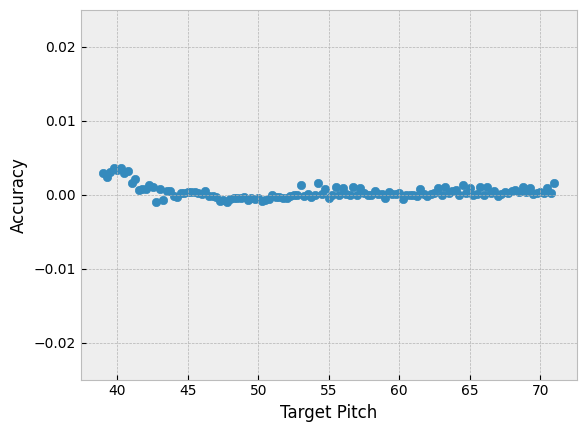

In [64]:
import matplotlib.pyplot as plt

# Define the lists of x and y values
x = target_pitches
y = s["raw_pitch_diffs"]

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the data as points
ax.scatter(x, y)

# Set the x and y axis labels
ax.set_xlabel('Target Pitch')
ax.set_ylabel('Accuracy')

# Set the y-axis limits
ax.set_ylim(-0.025, 0.025)

# Show the plot
plt.show()

In [74]:
import pandas as pd

REPEATS = 100

df = pd.DataFrame(columns=['iteration', 'raw_pitch_diffs'])

for i in range(REPEATS):
    print(f"iteration {i} our of {REPEATS}")
    r, s = analyze_audio(path_audio)

    df = df.append({
        'iteration': i,
        'target_pitches': target_pitches,
        'raw_pitch_diffs': s['raw_pitch_diffs']},
        ignore_index=True)

print(df)

iteration 0 our of 100
selected$("Sound")Plot saved


/var/folders/cm/m0503tnj4y596b5hp60r6_8m0000gr/T/ipykernel_91455/1248792235.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({


iteration 1 our of 100
selected$("Sound")Plot saved


/var/folders/cm/m0503tnj4y596b5hp60r6_8m0000gr/T/ipykernel_91455/1248792235.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({


iteration 2 our of 100
selected$("Sound")Plot saved


...

/var/folders/cm/m0503tnj4y596b5hp60r6_8m0000gr/T/ipykernel_91455/1248792235.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({


iteration 98 our of 100
selected$("Sound")Plot saved


/var/folders/cm/m0503tnj4y596b5hp60r6_8m0000gr/T/ipykernel_91455/1248792235.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({


iteration 99 our of 100
selected$("Sound")Plot saved
   iteration                                    raw_pitch_diffs  \
0          0  [0.002938372108943099, 0.0024263623207616547, ...   
1          1  [0.002938372108943099, 0.0024263623207616547, ...   
2          2  [0.002938372108943099, 0.0024263623207616547, ...   
3          3  [0.002938372108943099, 0.0024263623207616547, ...   
4          4  [0.002938372108943099, 0.0024263623207616547, ...   
..       ...                                                ...   
95        95  [0.002938372108943099, 0.0024263623207616547, ...   
96        96  [0.002938372108943099, 0.0024263623207616547, ...   
97        97  [0.002938372108943099, 0.0024263623207616547, ...   
98        98  [0.002938372108943099, 0.0024263623207616547, ...   
99        99  [0.002938372108943099, 0.0024263623207616547, ...   

                                       target_pitches  
0   [39.0, 39.25, 39.5, 39.75, 40.0, 40.25, 40.5, ...  
1   [39.0, 39.25, 39.5, 39.75,

/var/folders/cm/m0503tnj4y596b5hp60r6_8m0000gr/T/ipykernel_91455/1248792235.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({


In [75]:
df.to_csv("sing4me_simulations.csv", index=False)
